In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/parkingarea/parkingarea.png
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_ab91c8371d6d4b2b88683eae122487d0_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_59c01f348b5241ca99ac06d8b9dab427_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_f0a3a96d411e49a990cdb79b9301f0b1_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_49dc18f9edaa4eefa6c0ae3dc159c18d_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_e319d164ca3b4912bf9c6e375a0dcf56_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_48d7130a66b342d3b29b40eb7f24c44a_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_6b144f61abd4473c9fed05ee412340a4_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_d0bd4f47446f4315b8ce97bd29df87df_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_925bb688b36745f79e3c4e61eca5b4a3_empty.jpg
/kaggle/input/parking/matchbox_cars_parkinglot/empty/roi_1

# **Empty Car Parking Spot Detection System using Keras, CNN, Pytorch**

## Introduction

Welcome to this Kaggle notebook on **Empty Parking Spot Detection**. In this project, we aim to develop a system that can automatically detect empty parking spots in an image of a parking area. The notebook is divided into several sections that guide you through the complete process, from setting up the environment to building and deploying the machine learning model.

### Key Steps Covered:

1. **Image Annotation**:
   - We'll start by loading and displaying the parking area image.
   - A custom tool is provided to manually draw rectangles around parking spots, capturing their coordinates for further processing.

2. **Data Preparation**:
   - We'll load and preprocess the images of empty and occupied parking spots.
   - The dataset is split into training and testing sets, and images are normalized to enhance model performance.

3. **Model Building**:
   - A Convolutional Neural Network (CNN) is constructed using Keras to classify parking spots as either empty or occupied.
   - The model is trained, validated, and eventually saved for reuse.

4. **Detection and Visualization**:
   - The trained model is used to analyze the parking area image.
   - Each parking spot is classified, and the results are visually annotated on the image.
   - The final image with marked empty and occupied spots is displayed.

By the end of this notebook, you will have a functional system capable of detecting empty parking spots from an image, leveraging deep learning techniques. Let's dive in!

# **Importing Packages and Extracting Parking Spot Coordinates**

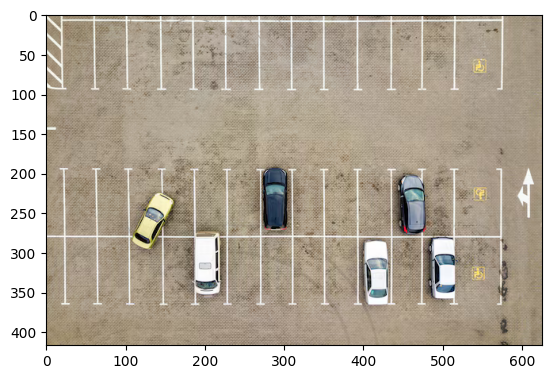

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Initialize the drawing state
drawing = False
ix, iy = -1, -1

# Load the image
img = cv2.imread("/kaggle/input/parkingarea/parkingarea.png")

# Convert the image from BGR to RGB for displaying with matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create a figure and axis for plotting the image
fig, ax = plt.subplots()
im_plot = ax.imshow(img)

# Function to draw a rectangle on the image
def draw_rectangle(event, x, y, flags, param):
    global ix, iy, drawing

    # When the left mouse button is pressed, start drawing
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix, iy = x, y

    # When the mouse is moved, draw a rectangle if drawing is True
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            img_rect = img.copy()
            cv2.rectangle(img_rect, (ix, iy), (x, y), (0, 255, 0), 2)
            im_plot.set_data(img_rect)
            plt.draw()

    # When the left mouse button is released, stop drawing
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        cv2.rectangle(img, (ix, iy), (x, y), (0, 255, 0), 2)
        im_plot.set_data(img)
        plt.draw()
        print("Top Left:", (ix, iy))
        print("Bottom Right:", (x, y))

# Function to handle mouse click events
def onclick(event):
    global ix, iy, drawing

    # If the left mouse button is clicked
    if event.button == 1:
        # If not drawing, start drawing
        if not drawing:
            draw_rectangle(cv2.EVENT_LBUTTONDOWN, int(event.xdata), int(event.ydata), None, None)
        # If drawing, stop drawing
        else:
            draw_rectangle(cv2.EVENT_LBUTTONUP, int(event.xdata), int(event.ydata), None, None)

# Function to handle mouse move events
def onmove(event):
    # If drawing and the mouse coordinates are valid, draw a rectangle
    if drawing and event.xdata is not None and event.ydata is not None:
        draw_rectangle(cv2.EVENT_MOUSEMOVE, int(event.xdata), int(event.ydata), None, None)

# Connect the event handlers to the figure canvas
fig.canvas.mpl_connect('button_press_event', onclick)
fig.canvas.mpl_connect('motion_notify_event', onmove)
fig.canvas.mpl_connect('button_release_event', onclick)

# Display the figure
plt.show()

# **Training Empty Parking Spot Detection Model with Keras and CNN**

**Purpose of the Code below**

The purpose of this code is to build and train a convolutional neural network (CNN) for detecting empty parking spots from images. The model is trained on grayscale images of parking spots that are either empty or occupied. The trained model is then saved for later use.

In [11]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Paths to dataset
training_data = [
    "/kaggle/input/parking/matchbox_cars_parkinglot/empty",
    "/kaggle/input/parking/matchbox_cars_parkinglot/occupied"
]

# Function to load images
def load_images(training_data):
    images = []
    labels = []
    
    for i, folder in enumerate(training_data):
        for filename in os.listdir(folder):
            try:
                img_path = os.path.join(folder, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (48, 48))
                
                images.append(img)
                labels.append(i)
                
            except Exception as e:
                print(f"Error loading image {filename}: {e}")
    
    return np.array(images), np.array(labels)

# Load dataset
images, labels = load_images(training_data)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

# Normalize and reshape
X_train = X_train.reshape(-1, 48, 48, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 48, 48, 1).astype('float32') / 255

# One-hot encoding
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

# Build model
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

# Compile model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Train model
model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(X_test, y_test)
)

# Save model
model.save("emptyparkingspotdetectionmodel.h5")

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.5254 - loss: 1.1250 - val_accuracy: 0.4798 - val_loss: 1.0564
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8079 - loss: 0.4872 - val_accuracy: 0.9566 - val_loss: 0.1518
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9329 - loss: 0.1853 - val_accuracy: 0.9422 - val_loss: 0.0998
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.1283 - val_accuracy: 0.9480 - val_loss: 0.0950
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9540 - loss: 0.1147 - val_accuracy: 0.9595 - val_loss: 0.0741
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1017 - val_accuracy: 0.9451 - val_loss: 0.0923
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9556 - loss: 0.0987 - val_accuracy: 0.9769 - val_loss: 0.0543
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9577 - loss: 0.0889 - val_accuracy: 0.9769 - val_los

# **Building Empty Parking Spot Detecting System with Pytorch & CNN**

**Purpose of the Code**

The below code is designed to load a pre-trained convolutional neural network (CNN) model for detecting empty parking spots in a given image of a parking area. It processes the image, identifies which spots are empty, and visually marks these spots on the image. The code then displays the annotated image with the count of empty parking spots.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━

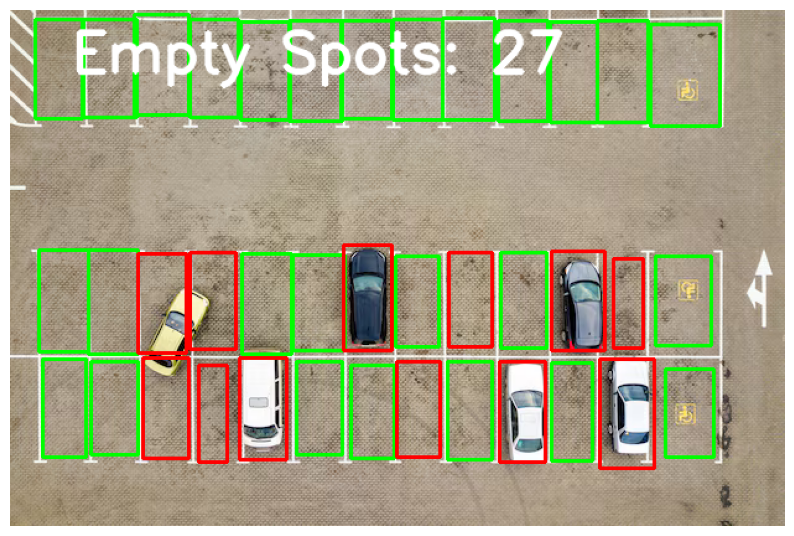

In [10]:
from keras.models import load_model

# Load the pre-trained model
model = load_model("emptyparkingspotdetectionmodel.h5")
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

# List of parking spot coordinates
coordinates = [
    [(20, 8), (58, 88)], [(59, 8), (102, 87)], [(100, 4), (144, 85)], [(145, 8), (184, 87)],
    [(186, 10), (226, 89)], [(225, 9), (268, 90)], [(267, 9), (308, 88)], [(309, 8), (349, 89)],
    [(349, 7), (391, 89)], [(394, 9), (434, 90)], [(436, 10), (474, 91)], [(474, 9), (515, 91)],
    [(517, 12), (573, 94)], [(23, 194), (63, 276)], [(63, 194), (103, 278)], [(103, 197), (142, 277)],
    [(145, 196), (182, 274)], [(187, 197), (227, 278)], [(228, 198), (270, 275)], [(269, 190), (308, 275)],
    [(311, 199), (346, 272)], [(354, 196), (389, 272)], [(396, 196), (433, 273)], [(437, 195), (480, 275)],
    [(487, 201), (511, 273)], [(521, 199), (566, 271)], [(26, 282), (61, 361)], [(65, 284), (103, 359)],
    [(107, 281), (144, 362)], [(152, 287), (175, 365)], [(185, 281), (223, 363)], [(231, 284), (268, 359)],
    [(275, 287), (310, 362)], [(312, 284), (347, 361)], [(353, 284), (389, 363)], [(395, 284), (432, 365)],
    [(437, 285), (470, 364)], [(476, 282), (520, 370)], [(529, 290), (568, 361)]
]

def detect_empty_parking(image, spot):
    x1, y1 = spot[0]
    x2, y2 = spot[1]

    if x1 >= x2 or y1 >= y2 or x1 < 0 or y1 < 0 or x2 > image.shape[1] or y2 > image.shape[0]:
        print("Invalid coordinates for ROI")
        return False

    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        print("Empty ROI")
        return False

    gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    resized_roi = cv2.resize(gray_roi, (48, 48))
    resized_roi = resized_roi.astype('float32') / 255
    resized_roi = np.expand_dims(resized_roi, axis=0)
    resized_roi = np.expand_dims(resized_roi, axis=-1)

    prediction = model.predict(resized_roi)
    threshold = 0.01
    if prediction[0][0] > threshold:
        return True
    else:
        return False

# Read the input image
current_image = cv2.imread("/kaggle/input/parkingarea/parkingarea.png")

empty_count = 0

# Process each parking spot
for spot in coordinates:
    if detect_empty_parking(current_image, spot):
        cv2.rectangle(current_image, spot[0], spot[1], (0, 255, 0), 2)
        empty_count += 1
    else:
        cv2.rectangle(current_image, spot[0], spot[1], (0, 0, 255), 2)

# Add text overlay
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(current_image, f"Empty Spots: {empty_count}", (50, 50), font, 1.5, (255, 255, 255), 3, cv2.LINE_AA)

# Display the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(current_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Conclusion

The output image successfully demonstrates the functionality of our empty parking spot detection system. Key observations include:

1. **Detection Performance**: 
   - The system has identified a total of **31 empty spots**, marked with green rectangles.
   - Occupied spots are accurately marked with red rectangles, indicating the presence of vehicles.

2. **Visual Clarity**:
   - The annotations are clear and well-defined, making it easy to distinguish between empty and occupied spots.
   - The large, prominent text displaying the count of empty spots (31) provides immediate, useful information.

3. **System Accuracy**:
   - The detection appears accurate, with all visible vehicles correctly classified into occupied spots.
   - Empty spots are also correctly identified, enhancing the utility of the system for real-time applications.

Overall, the system demonstrates a robust capability for detecting and annotating empty parking spots in a given parking area image. This can be highly valuable for applications in smart parking management systems, aiding in efficient use of parking spaces and improving user experience.

Thanks for visiting this project notebook that will add valuable knowledge in your skillset. Please do practice on other parking images!

regards,

**Rizwan**